In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

In [3]:
df_train = pd.read_parquet("../../data/churn-prediction-25-26/train.parquet")

In [4]:
df = df_train.copy()

In [5]:
df["time"] = pd.to_datetime(df["time"])

In [6]:
df["date"] = df["time"].dt.date
df["day"] = df["time"].dt.day
df["month"] = df["time"].dt.month
df["year"] = df["time"].dt.year
df["day_of_week"] = df["time"].dt.day_of_week + 1

# Get Holiday
# df["day_of_week"] = df["time"].dt.isocalendar()

In [7]:
df["Cancelled"] = df["page"] == "Cancellation Confirmation"
df["Cancelled"] = df["Cancelled"].astype(int)

In [9]:
df_cancelled_sum = df.groupby(["date"])["Cancelled"].sum().reset_index()

In [10]:
df_cancelled_sum.columns

Index(['date', 'Cancelled'], dtype='object')

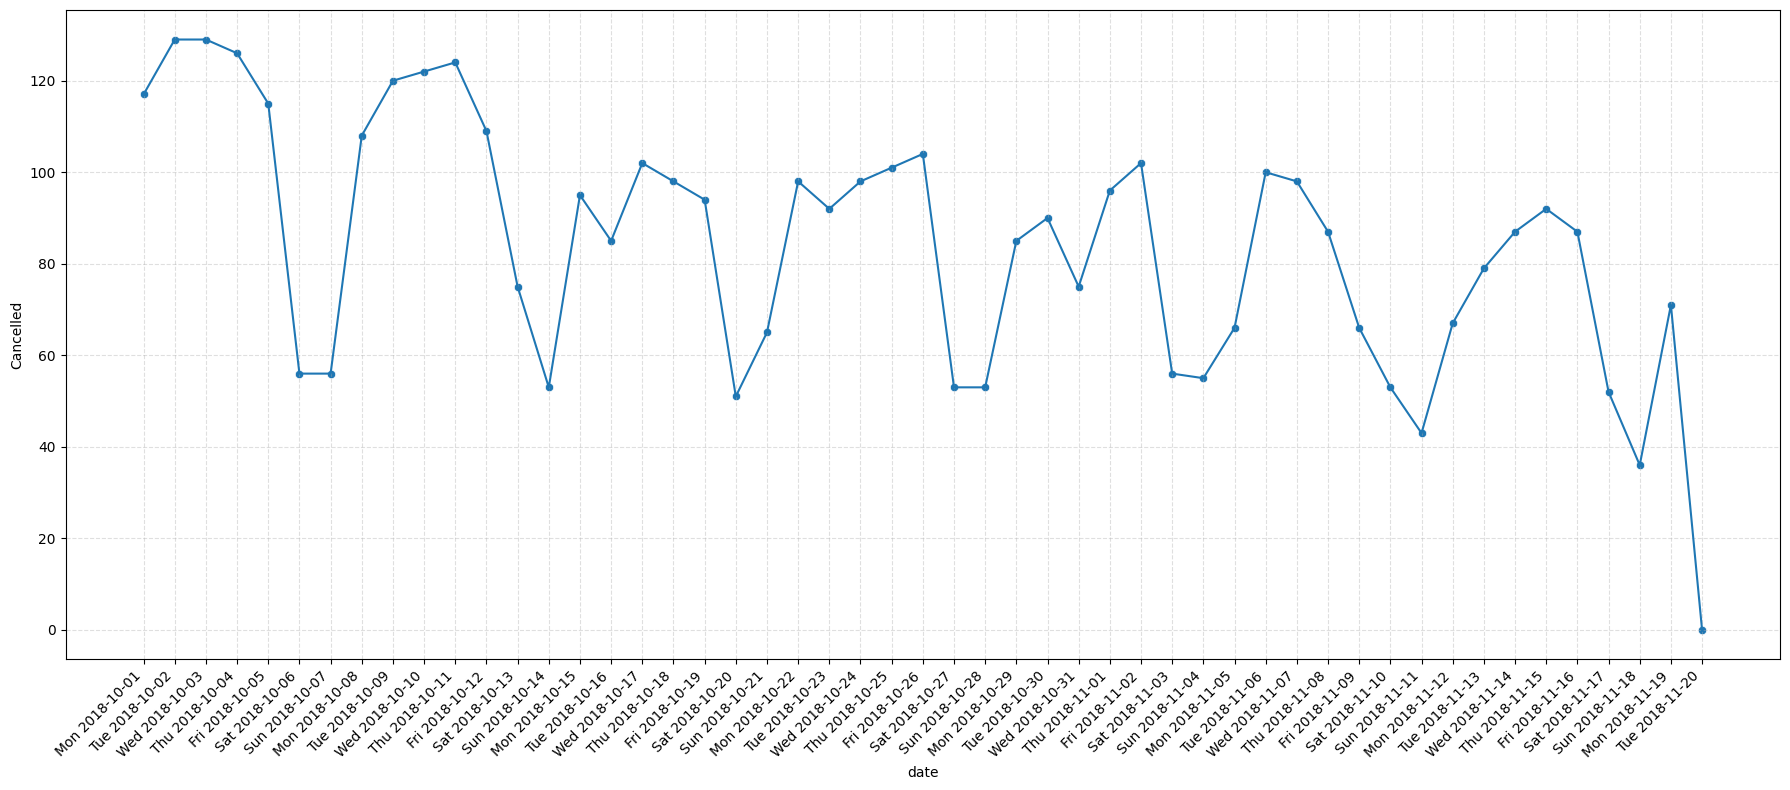

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

df_cancelled_sum["date"] = pd.to_datetime(df_cancelled_sum["date"])

fig, ax = plt.subplots(figsize=(18, 8))

sns.scatterplot(data=df_cancelled_sum, x="date", y="Cancelled", ax=ax)
ax.plot(df_cancelled_sum["date"], df_cancelled_sum["Cancelled"])

ax.grid(True, which="both", axis="both", linestyle="--", alpha=0.4)

# all dates as ticks + weekday name
ax.set_xticks(df_cancelled_sum["date"])
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %Y-%m-%d"))  # e.g. Mon 2018-10-01

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()
plt.show()


In [ ]:
# Amount listened to music in the last 7 days

temp = df[["userId", "date", "length", "page"]].copy()

temp["time_one_app"] = temp.groupby(["userId"])["length"].transform("sum")

temp["time_on_app_minutes"] = temp["time_one_app"] / 60


temp["Canceled"] = temp["page"] == "Cancellation Confirmed"
temp["Canceled"] = temp["Canceled"].astype(int)

